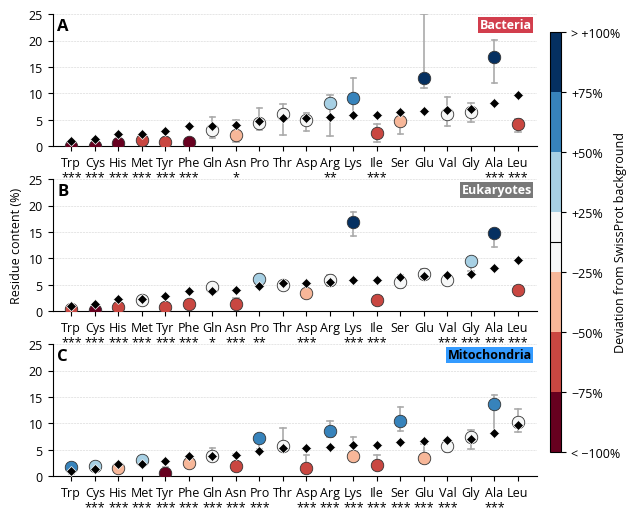

In [2]:
import os
import re
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib

matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams["font.family"] = "Open Sans"

BASE_DIR = ".."
RESULTS_AA_CONTENT_DIR = f"{BASE_DIR}/RESULTS_AA_CONTENT"
PLOT_DIR = f"{BASE_DIR}/PLOTS"

DOMAINS_TO_PLOT = ["bacteria", "eukaryotes", "mitochondria"]
PANEL_LABELS = ["A", "B", "C"]
DOMAIN_COLORS = {
    "bacteria": "#CE2939",
    "eukaryotes": "#696969",
    "mitochondria": "#1E90FF",
}

N_BOOTSTRAP = 10000
CONFIDENCE_LEVEL = 0.95
FDR_ALPHA = 0.05
MIN_N_FOR_STATS = 5

YLIM = (0, 25)
HSPACE = 0.25
PCT_BOUNDARIES = [-100, -75, -50, -25, 25, 50, 75, 100]
COLORBAR_TICKS = [-100, -75, -50, -25, 25, 50, 75, 100]
COLORBAR_TICKLABELS = ["< −100%", "−75%", "−50%", "−25%", "+25%", "+50%", "+75%", "> +100%"]

SWISSPROT = {
    "A": 8.25, "R": 5.53, "N": 4.06, "D": 5.45, "C": 1.37,
    "Q": 3.93, "E": 6.75, "G": 7.07, "H": 2.27, "I": 5.96,
    "L": 9.66, "K": 5.84, "M": 2.42, "F": 3.86, "P": 4.70,
    "S": 6.56, "T": 5.34, "W": 1.08, "Y": 2.92, "V": 6.87,
}

AA_NAMES = {
    "A": "Ala", "R": "Arg", "N": "Asn", "D": "Asp", "C": "Cys",
    "Q": "Gln", "E": "Glu", "G": "Gly", "H": "His", "I": "Ile",
    "L": "Leu", "K": "Lys", "M": "Met", "F": "Phe", "P": "Pro",
    "S": "Ser", "T": "Thr", "W": "Trp", "Y": "Tyr", "V": "Val",
}

AA_ORDER = sorted(SWISSPROT, key=lambda aa: SWISSPROT[aa])


def get_contrast_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if luminance > 0.5 else "white"


def make_colormap():
    n_intervals = len(PCT_BOUNDARIES) - 1
    colors = cm.RdBu(np.linspace(0, 1, n_intervals))
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries=PCT_BOUNDARIES, ncolors=n_intervals)
    return cmap, norm


def load_aa_contents(pdb_id):
    pdb_dir = os.path.join(RESULTS_AA_CONTENT_DIR, pdb_id)
    if not os.path.exists(pdb_dir):
        return None

    segments = defaultdict(dict)
    for fname in os.listdir(pdb_dir):
        if not fname.endswith(".npy"):
            continue
        match = re.match(r"^(.+)_(\d+)_([a-z])_content\.npy$", fname)
        if not match:
            continue
        chain_id, fragment_id, aa_lower = match.group(1), match.group(2), match.group(3)
        aa = aa_lower.upper()
        if aa not in SWISSPROT:
            continue
        value = float(np.load(os.path.join(pdb_dir, fname)))
        segments[(chain_id, fragment_id)][aa] = value

    complete = {k: v for k, v in segments.items() if len(v) == 20}
    if not complete:
        return None

    per_aa = defaultdict(list)
    for seg_values in complete.values():
        for aa, val in seg_values.items():
            per_aa[aa].append(val * 100)

    return per_aa


def bootstrap_median_ci(values, n_bootstrap=N_BOOTSTRAP, confidence=CONFIDENCE_LEVEL):
    values = np.array(values)
    bootstrap_medians = np.array([
        np.median(values[np.random.randint(0, len(values), len(values))])
        for _ in range(n_bootstrap)
    ])
    alpha = 1 - confidence
    ci_low = np.percentile(bootstrap_medians, 100 * alpha / 2)
    ci_high = np.percentile(bootstrap_medians, 100 * (1 - alpha / 2))
    return ci_low, ci_high


def bootstrap_pvalue(values, null_value, n_bootstrap=N_BOOTSTRAP):
    values = np.array(values)
    observed_median = np.median(values)
    bootstrap_medians = np.array([
        np.median(values[np.random.randint(0, len(values), len(values))])
        for _ in range(n_bootstrap)
    ])
    shifted = bootstrap_medians - observed_median + null_value
    p = 2 * min(
        np.mean(shifted < observed_median),
        np.mean(shifted > observed_median),
    )
    return float(np.clip(p, 1 / n_bootstrap, 1.0))


def fdr_bh(pvalues):
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked_pvals = np.array(pvalues)[order]
    adjusted = np.minimum(1.0, ranked_pvals * n / (np.arange(n) + 1))
    for i in range(n - 2, -1, -1):
        adjusted[i] = min(adjusted[i], adjusted[i + 1])
    result = np.empty(n)
    result[order] = adjusted
    return result


def significance_label(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def collect_domain_data(ribosome_info, domain):
    domain_pdb_ids = {
        entry["pdb_id"].upper() for entry in ribosome_info
        if entry["ribosome_class"] == domain
    }

    per_ribosome = {}
    for pdb_id in domain_pdb_ids:
        result = load_aa_contents(pdb_id)
        if result is None:
            continue
        ribosome_means = {}
        for aa in SWISSPROT:
            values = result.get(aa, [])
            if values:
                ribosome_means[aa] = float(np.mean(values))
        if len(ribosome_means) == 20:
            per_ribosome[pdb_id] = ribosome_means

    return per_ribosome


def compute_stats(per_ribosome):
    per_aa = {
        aa: [per_ribosome[pdb][aa] for pdb in per_ribosome]
        for aa in SWISSPROT
    }

    pct_change = {
        aa: (np.median(per_aa[aa]) - SWISSPROT[aa]) / SWISSPROT[aa] * 100
        for aa in SWISSPROT
    }

    ci_bounds = {
        aa: bootstrap_median_ci(per_aa[aa])
        for aa in SWISSPROT
    }

    raw_pvals = {
        aa: bootstrap_pvalue(per_aa[aa], SWISSPROT[aa])
        for aa in SWISSPROT
    }

    adj_pvals_arr = fdr_bh([raw_pvals[aa] for aa in SWISSPROT])
    adj_pvals = dict(zip(SWISSPROT.keys(), adj_pvals_arr))

    return per_aa, pct_change, ci_bounds, adj_pvals


def plot_panel(ax, per_aa, pct_change, ci_bounds, adj_pvals, domain,
               panel_label, run_stats, cmap, norm, show_xticklabels):
    domain_color = DOMAIN_COLORS[domain]

    for x_idx, aa in enumerate(AA_ORDER):
        values = per_aa[aa]
        color = cmap(norm(pct_change[aa]))
        observed_median = np.median(values)

        if run_stats:
            ci_low, ci_high = ci_bounds[aa]
            ci_high_clipped = min(ci_high, YLIM[1])
            ax.plot(
                [x_idx, x_idx], [ci_low, ci_high_clipped],
                color="#aaaaaa", linewidth=1.2, zorder=3,
            )
            ax.plot(
                [x_idx - 0.12, x_idx + 0.12], [ci_low, ci_low],
                color="#aaaaaa", linewidth=1.2, zorder=3,
            )
            ax.plot(
                [x_idx - 0.12, x_idx + 0.12], [ci_high_clipped, ci_high_clipped],
                color="#aaaaaa", linewidth=1.2, zorder=3,
            )

        ax.plot(
            x_idx, observed_median,
            marker="o", color=color, markersize=9,
            markeredgewidth=0.6, markeredgecolor="#333333",
            zorder=4,
        )

        ax.plot(
            x_idx, SWISSPROT[aa],
            marker="D", color="black",
            markersize=5, zorder=5,
            markeredgewidth=0.5, markeredgecolor="white",
        )

    ax.set_xlim(-0.8, len(AA_ORDER) - 0.2)
    ax.set_ylim(YLIM)
    ax.set_xticks(range(len(AA_ORDER)))

    if show_xticklabels:
        if run_stats:
            tick_labels = [
                f"{AA_NAMES[aa]}\n{significance_label(adj_pvals[aa])}"
                for aa in AA_ORDER
            ]
        else:
            tick_labels = [AA_NAMES[aa] for aa in AA_ORDER]
        ax.set_xticklabels(tick_labels)
    else:
        ax.set_xticklabels([])

    if domain == DOMAINS_TO_PLOT[1]:
        ax.set_ylabel("Residue content (%)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.4, color="lightgray", zorder=0)
    ax.set_axisbelow(True)

    ax.text(
        0.01, 0.97, panel_label,
        transform=ax.transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="left",
    )

    ax.text(
        0.99, 0.97, f"{domain.capitalize()}",
        transform=ax.transAxes,
        fontweight="bold",
        va="top", ha="right",
        bbox=dict(facecolor=domain_color, edgecolor="none", pad=1, alpha=0.9),
        color=get_contrast_color(domain_color),
    )


with open(os.path.join(BASE_DIR, "ribosome_info.json")) as f:
    ribosome_info = json.load(f)

cmap, norm = make_colormap()

fig, axes = plt.subplots(
    len(DOMAINS_TO_PLOT), 1,
    figsize=(6.5, 6),
)
fig.subplots_adjust(hspace=HSPACE, right=0.87)

for ax, domain, panel_label in zip(axes, DOMAINS_TO_PLOT, PANEL_LABELS):
    per_ribosome = collect_domain_data(ribosome_info, domain)
    n = len(per_ribosome)

    per_aa, pct_change, ci_bounds, adj_pvals = compute_stats(per_ribosome)

    show_xticklabels = True
    run_stats = True
    plot_panel(
        ax, per_aa, pct_change, ci_bounds, adj_pvals,
        domain, panel_label, run_stats, cmap, norm,
        show_xticklabels,
    )

cbar_ax = fig.add_axes([0.89, 0.15, 0.018, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=COLORBAR_TICKS)
cbar.ax.set_yticklabels(COLORBAR_TICKLABELS)
cbar.set_label("Deviation from SwissProt background", fontsize=9, labelpad=-5)
cbar.ax.axhline(0, color="black", linewidth=0.8)

os.makedirs(PLOT_DIR, exist_ok=True)
out_path = os.path.join(PLOT_DIR, "aa_composition_by_domain.png")
plt.savefig(out_path, bbox_inches="tight", dpi=300)